# EE 446 TinyML — Knowledge Distillation with Pruning and Quantization  

## Student TODO Version: Compression of a DNN Using the UCI Human Activity Recognition Dataset

In this version, key parts of the notebook have been left for you to complete.  
Follow the instructions in each code cell and fill in the missing sections marked with `#<--- Enter your code here --->#`.


## 1. Environment Setup

This notebook assumes you are running it with the **`Python (tinyml-arduino)`** kernel.

Expected environment:
- TensorFlow 2.14.1
- TensorFlow Model Optimization 0.8.0
- NumPy, Pandas, Matplotlib, Scikit-learn
- No in-notebook package reinstallation is required

Use **Kernel → Change Kernel → `Python (tinyml-arduino)`** if needed.


In [1]:

import os
import math
import zipfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


2026-04-23 20:29:00.138791: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 20:29:00.141207: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 20:29:00.169968: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-23 20:29:00.170029: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-23 20:29:00.170077: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

TensorFlow version: 2.14.1


## 2. Download and Extract the UCI HAR Dataset

The UCI HAR dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 human activity classes**
- A predefined **training split** and **test split**

This makes it a strong fit for a **fully connected DNN** and for TinyML-oriented compression experiments.


In [2]:

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = Path("uci_har_dataset.zip")
extract_dir = Path(".")

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

dataset_root = Path("UCI HAR Dataset")
if not dataset_root.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("Dataset ready at:", dataset_root.resolve())


Dataset ready at: /mnt/c/Users/bobby/Downloads/tinyml_env_setup_package/tinyml_env_setup_package/UCI HAR Dataset


## 3. Load the Data


In [3]:

def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)

    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32 and subtract 1
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32 and subtract 1

    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(int) - 1

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(int) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data(dataset_root)

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection


In [4]:

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Define the Teacher and Student Models

The **teacher model** is intentionally larger and more expressive.  
The **student model** is smaller and is the model we ultimately want to deploy.


In [5]:

def build_teacher_model(input_dim, num_classes):
    # TODO:
    # Build a larger teacher DNN suitable for 561 numerical input features.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        #<--- Enter your code here --->#,
        #<--- Enter your code here --->#,
        #<--- Enter your code here --->#,
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def build_student_model(input_dim, num_classes):
    # TODO:
    # Build a smaller student DNN.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        #<--- Enter your code here --->#,
        #<--- Enter your code here --->#,
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

teacher_model = build_teacher_model(num_features, num_classes)
student_baseline_model = build_student_model(num_features, num_classes)

teacher_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               287744    
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 6)                 774       
                                                                 
Total params: 452742 (1.73 MB)
Trainable params: 452742 (1.73 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 6. Train the Teacher Model


In [6]:

teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the teacher model on the UCI HAR training split.
teacher_history = teacher_model.fit(
    #<--- Enter your code here --->#
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=teacher_callbacks,
    verbose=1
)


Epoch 1/40
92/92 [==============================] - 1s 7ms/step - loss: 0.4249 - accuracy: 0.8152 - val_loss: 0.1898 - val_accuracy: 0.9205
Epoch 2/40
92/92 [==============================] - 1s 6ms/step - loss: 0.1608 - accuracy: 0.9344 - val_loss: 0.1349 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 1s 6ms/step - loss: 0.1034 - accuracy: 0.9570 - val_loss: 0.3650 - val_accuracy: 0.8674
Epoch 4/40
92/92 [==============================] - 1s 6ms/step - loss: 0.0911 - accuracy: 0.9648 - val_loss: 0.1948 - val_accuracy: 0.9327
Epoch 5/40
92/92 [==============================] - 1s 6ms/step - loss: 0.0943 - accuracy: 0.9629 - val_loss: 0.1453 - val_accuracy: 0.9402
Epoch 6/40
92/92 [==============================] - 1s 5ms/step - loss: 0.0699 - accuracy: 0.9745 - val_loss: 0.2183 - val_accuracy: 0.9252
Epoch 7/40
92/92 [==============================] - 1s 6ms/step - loss: 0.0663 - accuracy: 0.9755 - val_loss: 0.1348 - val_accuracy: 0.9477
Epoch 8/40
92/92 [==

### Teacher Training Curves


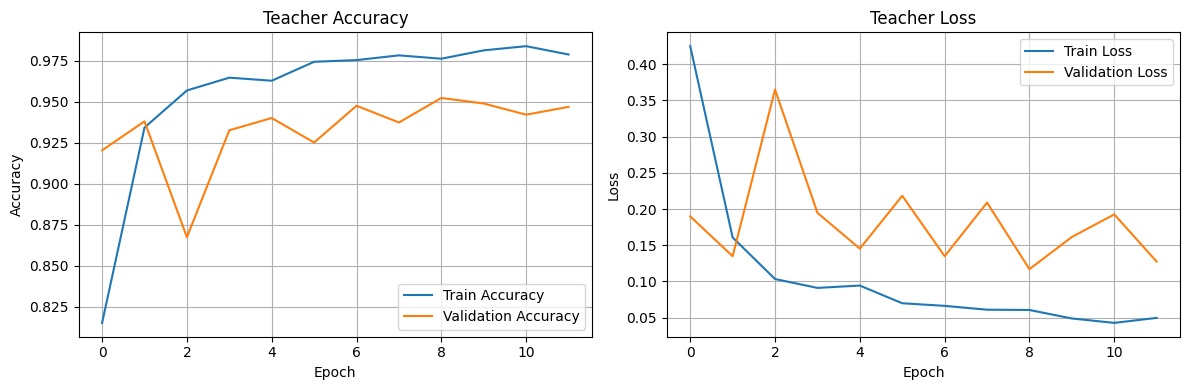

In [7]:

teacher_history_df = pd.DataFrame(teacher_history.history)

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(teacher_history_df["accuracy"], label="Train Accuracy")
plt.plot(teacher_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Teacher Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(teacher_history_df["loss"], label="Train Loss")
plt.plot(teacher_history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Teacher Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 7. Evaluate the Teacher Model


In [8]:
teacher_probs = teacher_model.predict(X_test, verbose=0)
teacher_preds = np.argmax(teacher_probs, axis=1)
teacher_acc = accuracy_score(y_test, teacher_preds)

print(f"Teacher Test Accuracy: {teacher_acc:.4f}\n")
print(classification_report(y_test, teacher_preds, target_names=class_names, digits=4))


Teacher Test Accuracy: 0.9376

                    precision    recall  f1-score   support

           WALKING     0.9364    0.9798    0.9576       496
  WALKING_UPSTAIRS     0.9578    0.9151    0.9359       471
WALKING_DOWNSTAIRS     0.9570    0.9548    0.9559       420
           SITTING     0.9093    0.8982    0.9037       491
          STANDING     0.8746    0.9173    0.8954       532
            LAYING     1.0000    0.9609    0.9801       537

          accuracy                         0.9376      2947
         macro avg     0.9392    0.9377    0.9381      2947
      weighted avg     0.9387    0.9376    0.9378      2947



## 8. Train a Baseline Student Model (Hard Labels Only)

Before applying knowledge distillation, we train the smaller student model in the standard way.  
This gives us a fair baseline for comparison.


In [9]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 4ms/step - loss: 0.5301 - accuracy: 0.8123 - val_loss: 0.2443 - val_accuracy: 0.9103
Epoch 2/20
92/92 [==============================] - 0s 2ms/step - loss: 0.1845 - accuracy: 0.9345 - val_loss: 0.1950 - val_accuracy: 0.9177
Epoch 3/20
92/92 [==============================] - 0s 2ms/step - loss: 0.1514 - accuracy: 0.9415 - val_loss: 0.2699 - val_accuracy: 0.9123
Epoch 4/20
92/92 [==============================] - 0s 2ms/step - loss: 0.1158 - accuracy: 0.9565 - val_loss: 0.1503 - val_accuracy: 0.9347
Epoch 5/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0891 - accuracy: 0.9663 - val_loss: 0.1711 - val_accuracy: 0.9252
Epoch 6/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0669 - accuracy: 0.9779 - val_loss: 0.2556 - val_accuracy: 0.9184
Epoch 7/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0642 - accuracy: 0.9765 - val_loss: 0.1501 - val_accuracy: 0.9381
Epoch 8/20
92/92 [==

## 9. Evaluate the Baseline Student Model


In [10]:
student_probs = student_baseline_model.predict(X_test, verbose=0)
student_preds = np.argmax(student_probs, axis=1)
student_acc = accuracy_score(y_test, student_preds)

print(f"Baseline Student Test Accuracy: {student_acc:.4f}\n")
print(classification_report(y_test, student_preds, target_names=class_names, digits=4))

Baseline Student Test Accuracy: 0.9328

                    precision    recall  f1-score   support

           WALKING     0.9587    0.9819    0.9701       496
  WALKING_UPSTAIRS     0.9026    0.9639    0.9322       471
WALKING_DOWNSTAIRS     0.9682    0.8690    0.9159       420
           SITTING     0.9239    0.8900    0.9066       491
          STANDING     0.8611    0.9323    0.8953       532
            LAYING     1.0000    0.9497    0.9742       537

          accuracy                         0.9328      2947
         macro avg     0.9357    0.9311    0.9324      2947
      weighted avg     0.9352    0.9328    0.9330      2947



In [11]:

class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.3,
        temperature=4.0,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data

        # TODO:
        # 1. Obtain teacher predictions with training=False
        # 2. Compute student predictions inside GradientTape
        # 3. Compute student_loss using the hard labels
        # 4. Compute distillation_loss using softened teacher/student outputs
        # 5. Combine the two losses using alpha
        #teacher_predictions = #<--- Enter your code here --->#
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            #student_predictions = #<--- Enter your code here --->#
            student_predictions = self.student(x, training=True)
            #student_loss = #<--- Enter your code here --->#
            student_loss = self.student_loss_fn(y, student_predictions)
            #distillation_loss = #<--- Enter your code here --->#
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1),
            ) * (self.temperature ** 2)
            #loss = #<--- Enter your code here --->#
            loss = self.alpha * student_loss + (1.0 - self.alpha) * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss,
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results


# Part I: Knowledge Distillation

## 10. Distillation Utilities

The distilled student is trained to optimize:
- a **hard-label loss** using the true class labels
- a **soft-label loss** using the teacher's softened probability distribution


In [12]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the distilled student.
distillation_history = distiller.fit(
    #<--- Enter your code here --->#
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 5ms/step - accuracy: 0.7992 - student_loss: 0.5483 - distillation_loss: 0.0246 - val_accuracy: 0.9259 - val_student_loss: 0.0592
Epoch 2/20
92/92 [==============================] - 0s 4ms/step - accuracy: 0.9350 - student_loss: 0.1880 - distillation_loss: 0.0071 - val_accuracy: 0.9232 - val_student_loss: 0.0078
Epoch 3/20
92/92 [==============================] - 0s 4ms/step - accuracy: 0.9480 - student_loss: 0.1416 - distillation_loss: 0.0050 - val_accuracy: 0.9218 - val_student_loss: 0.0091
Epoch 4/20
92/92 [==============================] - 0s 4ms/step - accuracy: 0.9599 - student_loss: 0.1086 - distillation_loss: 0.0032 - val_accuracy: 0.9368 - val_student_loss: 0.0034
Epoch 5/20
92/92 [==============================] - 0s 4ms/step - accuracy: 0.9706 - student_loss: 0.0832 - distillation_loss: 0.0021 - val_accuracy: 0.9300 - val_student_loss: 7.9298e-04
Epoch 6/20
92/92 [==============================] - 0s 4ms/step - accuracy: 

## 11. Train the Distilled Student


In [13]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 5ms/step - accuracy: 0.7693 - student_loss: 0.6033 - distillation_loss: 0.0279 - val_accuracy: 0.9137 - val_student_loss: 0.0619
Epoch 2/20
92/92 [==============================] - 0s 3ms/step - accuracy: 0.9211 - student_loss: 0.2113 - distillation_loss: 0.0086 - val_accuracy: 0.9143 - val_student_loss: 0.0140
Epoch 3/20
92/92 [==============================] - 0s 3ms/step - accuracy: 0.9427 - student_loss: 0.1507 - distillation_loss: 0.0056 - val_accuracy: 0.9225 - val_student_loss: 0.0140
Epoch 4/20
92/92 [==============================] - 0s 3ms/step - accuracy: 0.9572 - student_loss: 0.1172 - distillation_loss: 0.0037 - val_accuracy: 0.9354 - val_student_loss: 0.0066
Epoch 5/20
92/92 [==============================] - 0s 4ms/step - accuracy: 0.9691 - student_loss: 0.0865 - distillation_loss: 0.0022 - val_accuracy: 0.9313 - val_student_loss: 0.0013
Epoch 6/20
92/92 [==============================] - 0s 4ms/step - accuracy: 0.97

### Distillation Training Curves


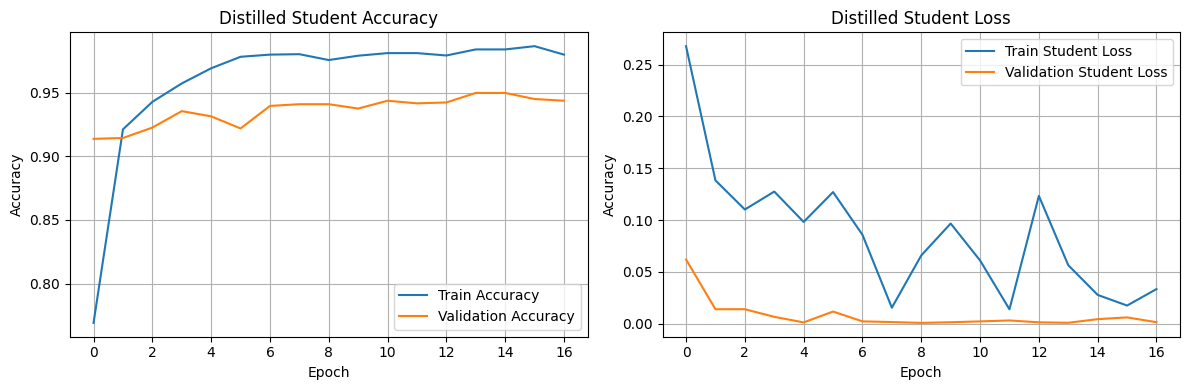

In [14]:

distillation_history_df = pd.DataFrame(distillation_history.history)

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(distillation_history_df["accuracy"], label="Train Accuracy")
plt.plot(distillation_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Distilled Student Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(distillation_history_df["student_loss"], label="Train Student Loss")
plt.plot(distillation_history_df["val_student_loss"], label="Validation Student Loss")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Distilled Student Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 12. Evaluate the Distilled Student


Distilled Student Test Accuracy: 0.9348

                    precision    recall  f1-score   support

           WALKING     0.9328    0.9798    0.9558       496
  WALKING_UPSTAIRS     0.9497    0.9214    0.9353       471
WALKING_DOWNSTAIRS     0.9587    0.9405    0.9495       420
           SITTING     0.9093    0.8982    0.9037       491
          STANDING     0.8696    0.9154    0.8919       532
            LAYING     1.0000    0.9534    0.9762       537

          accuracy                         0.9348      2947
         macro avg     0.9367    0.9348    0.9354      2947
      weighted avg     0.9361    0.9348    0.9351      2947



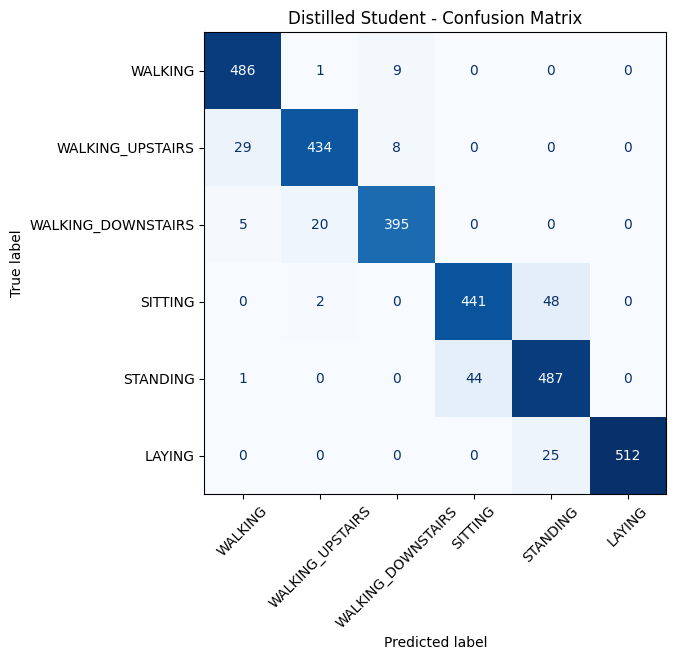

In [15]:

distilled_probs = distilled_student.predict(X_test, verbose=0)
distilled_preds = np.argmax(distilled_probs, axis=1)
distilled_acc = accuracy_score(y_test, distilled_preds)

print(f"Distilled Student Test Accuracy: {distilled_acc:.4f}\n")
print(classification_report(y_test, distilled_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, distilled_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Distilled Student - Confusion Matrix")
plt.show()


## 13. Part I Comparison: Teacher vs Student vs Distilled Student


In [16]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input when the model expects int8/uint8 input.
        if input_details["dtype"] == np.int8:
            #x = #<--- Enter your code here --->#
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            #x = #<--- Enter your code here --->#
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output when needed.
        if output_details["dtype"] == np.int8:
            #output = #<--- Enter your code here --->#
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            #output = #<--- Enter your code here --->#
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    # TODO:
    # Yield small batches from X_train for calibration.
    for i in range(300):#<--- Enter your code here --->#):
        #yield [#<--- Enter your code here --->#]
        yield [X_train[i:i+1].astype(np.float32)]


# Part II: Pruning and Quantization of the Distilled Student

## 14. TensorFlow Lite Utilities


In [17]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()
'''
def representative_data_gen():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1]]
'''
def representative_data_gen():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]


## 15. Convert the Distilled Student to TensorFlow Lite


In [18]:
pruning_epochs = 10
batch_size = 64
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# 1. Clone the distilled student model.
# 2. Copy the distilled student weights into the cloned model.
# 3. Wrap the cloned model using prune_low_magnitude with pruning_params.
#student_for_pruning = #<--- Enter your code here --->#
#<--- Enter your code here --->#
student_for_pruning = keras.models.clone_model(distilled_student)
student_for_pruning.set_weights(distilled_student.get_weights())

#pruned_distilled_model = #<--- Enter your code here --->#
pruned_distilled_model = prune_low_magnitude(
    student_for_pruning,
    **pruning_params
)

pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Fine-tune the pruned distilled model using:
# - X_train and y_train
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks
# - verbose=1
pruning_history = pruned_distilled_model.fit(
    #<--- Enter your code here --->#
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)

Epoch 1/10
92/92 [==============================] - 1s 4ms/step - loss: 0.0326 - accuracy: 0.9884 - val_loss: 0.1539 - val_accuracy: 0.9463
Epoch 2/10
92/92 [==============================] - 0s 2ms/step - loss: 0.0372 - accuracy: 0.9883 - val_loss: 0.1400 - val_accuracy: 0.9490
Epoch 3/10
92/92 [==============================] - 0s 2ms/step - loss: 0.0563 - accuracy: 0.9862 - val_loss: 0.1138 - val_accuracy: 0.9558
Epoch 4/10
92/92 [==============================] - 0s 3ms/step - loss: 0.0845 - accuracy: 0.9762 - val_loss: 0.1224 - val_accuracy: 0.9565
Epoch 5/10
92/92 [==============================] - 0s 3ms/step - loss: 0.3770 - accuracy: 0.8971 - val_loss: 0.1573 - val_accuracy: 0.9565
Epoch 6/10
92/92 [==============================] - 0s 2ms/step - loss: 1.0748 - accuracy: 0.7558 - val_loss: 1.1227 - val_accuracy: 0.6635
Epoch 7/10
92/92 [==============================] - 0s 2ms/step - loss: 0.9504 - accuracy: 0.5705 - val_loss: 0.7475 - val_accuracy: 0.6390


## 16. Apply Magnitude-Based Pruning to the Distilled Student


In [19]:

# TODO:
# Convert the pruned model with the pruning wrappers still attached.
#pruned_with_mask_tflite = #<--- Enter your code here --->#
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_distilled_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_distilled_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

# TODO:
# Strip the pruning wrappers and convert again using sparse optimization.
#stripped_pruned_model = #<--- Enter your code here --->#
stripped_pruned_model = strip_pruning(pruned_distilled_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "distilled_stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned distilled model with mask accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned distilled model with mask size (KB): {pruned_with_mask_size_kb:.2f}")
print(f"Stripped sparse distilled model accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped sparse distilled model size (KB): {stripped_sparse_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmp6d_8z76l/assets


INFO:tensorflow:Assets written to: /tmp/tmp6d_8z76l/assets
2026-04-23 20:29:33.834768: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 20:29:33.834828: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 20:29:33.835089: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp6d_8z76l
2026-04-23 20:29:33.837475: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 20:29:33.837497: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp6d_8z76l
2026-04-23 20:29:33.846864: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-23 20:29:33.847981: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 20:29:33.886897: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

INFO:tensorflow:Assets written to: /tmp/tmpkvaep_85/assets


INFO:tensorflow:Assets written to: /tmp/tmpkvaep_85/assets


Pruned distilled model with mask accuracy: 0.9355
Pruned distilled model with mask size (KB): 634.69
Stripped sparse distilled model accuracy: 0.9355
Stripped sparse distilled model size (KB): 165.73


2026-04-23 20:29:34.350534: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 20:29:34.350609: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 20:29:34.350781: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpkvaep_85
2026-04-23 20:29:34.351244: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 20:29:34.351256: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpkvaep_85
2026-04-23 20:29:34.352805: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 20:29:34.362349: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpkvaep_85
2026-04-23 20:29:34.366282: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 15500 m

## 17. Convert the Pruned Distilled Student Before and After Stripping


In [20]:

# TODO:
# Configure the converter for full integer quantization of the stripped sparse model.
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
#converter.optimizations = #<--- Enter your code here --->#
#converter.representative_dataset = #<--- Enter your code here --->#
#converter.target_spec.supported_ops = #<--- Enter your code here --->#
#converter.inference_input_type = #<--- Enter your code here --->#
#converter.inference_output_type = #<--- Enter your code here --->#

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmpj3hc6y0v/assets


INFO:tensorflow:Assets written to: /tmp/tmpj3hc6y0v/assets


Stripped Sparse + INT8 Accuracy: 0.9342
Stripped Sparse + INT8 Size (KB): 81.78


/home/btaing14/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 20:29:34.691140: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 20:29:34.691196: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 20:29:34.691335: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpj3hc6y0v
2026-04-23 20:29:34.691655: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 20:29:34.691664: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpj3hc6y0v
2026-04-23 20:29:34.692453: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 20:29:34.703623: I tensorflow/cc/saved_model/loa

## 18. Apply Full Integer Quantization to the Stripped Sparse Distilled Student


In [21]:

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmpz5_4n02x/assets


INFO:tensorflow:Assets written to: /tmp/tmpz5_4n02x/assets


Stripped Sparse + INT8 Accuracy: 0.9342
Stripped Sparse + INT8 Size (KB): 84.05


/home/btaing14/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 20:29:35.007057: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 20:29:35.007107: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 20:29:35.007245: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpz5_4n02x
2026-04-23 20:29:35.007705: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 20:29:35.007715: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpz5_4n02x
2026-04-23 20:29:35.008894: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 20:29:35.018425: I tensorflow/cc/saved_model/loa

## 19. Part II Comparison: Distillation, Pruning, and Quantization


In [22]:
# Convert distilled student to FP32 TFLite
distilled_fp32_tflite = convert_to_tflite_fp32(distilled_student)

distilled_fp32_size_kb = save_binary_model(
    distilled_fp32_tflite,
    "distilled_student_fp32.tflite"
)

distilled_fp32_acc, distilled_fp32_preds = evaluate_tflite_model(
    distilled_fp32_tflite,
    X_test,
    y_test
)

print(f"Distilled FP32 Accuracy: {distilled_fp32_acc:.4f}")
print(f"Distilled FP32 Size (KB): {distilled_fp32_size_kb:.2f}")

INFO:tensorflow:Assets written to: /tmp/tmpoh022ejk/assets


INFO:tensorflow:Assets written to: /tmp/tmpoh022ejk/assets
2026-04-23 20:29:35.731113: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 20:29:35.731168: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 20:29:35.731309: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpoh022ejk
2026-04-23 20:29:35.732051: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 20:29:35.732064: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpoh022ejk
2026-04-23 20:29:35.733337: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 20:29:35.743322: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpoh022ejk
2026-04-23 20:29:35.748426: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

Distilled FP32 Accuracy: 0.9348
Distilled FP32 Size (KB): 316.89


In [23]:

part2_results = pd.DataFrame([
    ["Distilled Student TFLite", "FP32", distilled_fp32_acc, distilled_fp32_size_kb],
    ["Pruned Distilled TFLite (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Distilled TFLite", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Stripped Sparse Distilled TFLite", "INT8 + Sparse", stripped_sparse_int8_acc, stripped_sparse_int8_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Distilled Student TFLite,FP32,0.934849,316.886719
1,Pruned Distilled TFLite (with mask),FP32,0.935528,634.687500
2,Stripped Sparse Distilled TFLite,FP32 + Sparse,0.935528,165.726562
3,Stripped Sparse Distilled TFLite,INT8 + Sparse,0.934170,84.054688


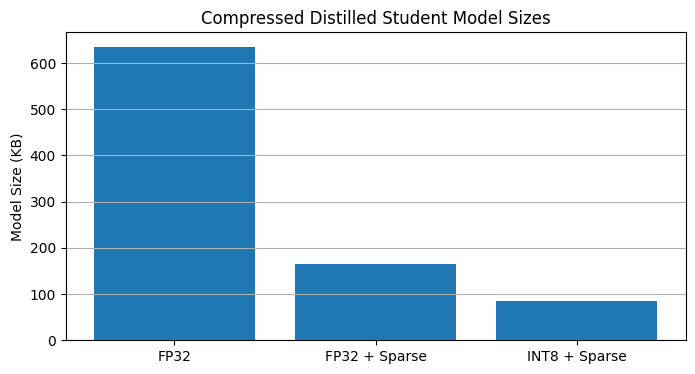

In [24]:

plt.figure(figsize=(8, 4))
plt.bar(part2_results["Format"], part2_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Compressed Distilled Student Model Sizes")
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the Final Sparse INT8 Distilled Student


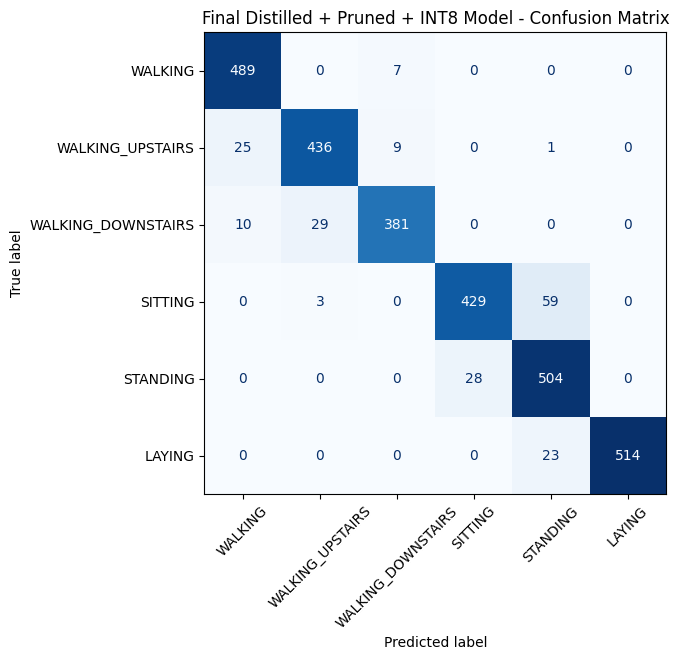

In [25]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Final Distilled + Pruned + INT8 Model - Confusion Matrix")
plt.show()


## 20. Summary Questions

Answer the following in your lab report:
1. How did the **baseline student** compare with the **distilled student**?
2. Did **knowledge distillation** help the smaller model retain performance?
3. What happened to the model size after **pruning** and after **INT8 quantization**?
4. Which model would you choose for **Arduino deployment**, and why?
5. Why is the final **sparse INT8 model** a good TinyML deployment candidate?


1. Both have achieved similar test accuracy around 93.5%. 
   The distilled matched the baseline while using the same small architecture, 
   showing that teacher guidance helped learning efficiency.
2. Yes, it helped retain performance close to the larger teacher model by 
   learning from both hard labels and the teacher's soft probability outputs.
3. Pruning alone did not always reduce the exported model size 
   because pruning masks add overhead. After stripping pruning wrappers and 
   applying sparse optimization, size dropped signficantly, then reduced even 
   further after applying INT8 quantization, producing the smallest final model.
4. The final sparse INT8 distilled student model because it has the best balance
   of compact size, fast integer inference, and strong accuracy.
5. It is memory-efficient, computationally efficient, and still maintains
   high classification accuracy. Its small footprint makes it practical for
   resource-constrained MCUs.

## 21. Submission Requirements

Submit the following:
1. Your completed notebook
2. Screenshots of the most important results:
   - teacher accuracy
   - baseline student accuracy
   - distilled student accuracy
   - final sparse INT8 model accuracy and size
3. The exported TensorFlow Lite model:
   - `distilled_stripped_sparse_int8.tflite`
4. Short answers to the summary questions
